In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brentq
from scipy.integrate import ode, odeint

import sys
import os

sys.path.append(os.path.abspath('..')) 
import WD.opacity as op
import Physical_Const as phys

#----Constants------

hbar     = phys.hbar
c        = phys.c
G        = phys.G
SigmaSB  = phys.sigmaSB
me_mev   = phys.me
mp_mev   = phys.mp
e        = phys.e
e_erg    = phys.e_erg
mevtoerg = phys.mevtoerg
mu       = phys.mu 
kappaB   = phys.kappa
Msun     = phys.Msun
Rsun     = phys.Rsun
Lsun     = phys.Lsun

h        = hbar*(2.0*np.pi)
c2       = c*c
me       = me_mev * mevtoerg / c2
mp       = mp_mev * mevtoerg / c2

arad     = 4.0*SigmaSB / c
Tr       = me * c2 / kappaB
pi05     = np.sqrt(np.pi)
RBohr    = hbar**2 / (me*e_erg)
yr       = (364)*24*60*60
avo      = 1.0 / mu


# ---Dimensions---
MA       = 2.0
Cgrav    = G * Msun / c**2
Jdim     = G / c**3

mpl      = np.sqrt(hbar * c / G) # planck mass
Rdim     = np.power( mpl / me , 2.0) * hbar / (mpl * c)
Mdim     = Rdim / Cgrav
Sigma02  = np.power( c / Rdim,2.0) / G

Sigma    = np.pi * me * np.power(me*c / h ,3.0) 
SigmaP   = c2 * Sigma
rhodim   = ( ( mu * MA / me ) * 8.0* Sigma / 3.0 )

Tdim     = ( MA * mu *c2) / kappaB

Ldim     =  4.0 * np.pi * Rdim**2 * SigmaSB * Tdim**4
kappaK   =  4.34e24  * ( Sigma02 / Tdim**3.5 ) * ( c2 / G ) *( 1 / Rdim)


Bdim     =  np.sqrt(G )  * Rdim / c2  
Jadim    = 1e50
JJdim    = Jadim * Jdim  / Rdim**2
rhobeta  = np.log10(3.9e10)


/home/laura/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


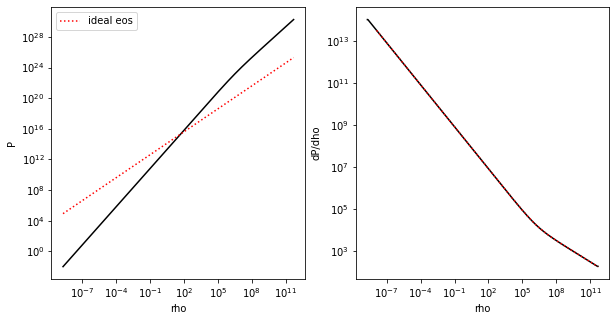

In [2]:
#---degenerate pressure-------------
def Pch_EoS(x):
    x2  = x*x
    
    if x > 2e-3:
        ww  = np.sqrt( 1.0 + x2) + x 
        pWD = x * np.sqrt( 1.0 + x2 ) * ( 2.0 * x2/3.0  - 1.0 ) +  np.log( ww ) 
    else:
        x3 = x2*x
        x5 = x3*x2
        x7 = x5*x2
        x9 = x7*x2
        x11 = x9*x2
        pWD = -2.77556e-17*x3 + 0.533333*x5 - 0.190476*x7 + 0.111111*x9 - 0.0757576*x11
    
    return SigmaP *pWD
   
def func(x):
    return  rhodim *np.power(x,3)

def DpDe_ch(x):
    x2   = x*x
    Dedx = 3.0 * rhodim * x**2
    Dpdx = SigmaP * 8.0 * x**4 / ( 3.0 * np.sqrt( 1.0 + x2 ) )
    
    return Dedx/Dpdx
    

NN      = 500
log_xXe = np.linspace( -5, 1.8,NN)
xx_xe   = np.power(10.0,log_xXe)

P_RFMT   = np.zeros(NN)
rho_RFMT = np.zeros(NN)
DeDp     = np.zeros(NN)
DeDp2    = np.zeros(NN)

for i in range(NN):
    xi          = xx_xe[i]
    P_RFMT[i]   = Pch_EoS(xi) / (c**2*Sigma02)
    rho_RFMT[i] = func(xi)  / Sigma02
    DeDp2[i]    = c**2*DpDe_ch(xi)

DxeF = 0.01
for i in range(NN):
    
    if i==0:
        Der = ( rho_RFMT[i+2] - rho_RFMT[0] ) / (  P_RFMT[i+2] - P_RFMT[0] )
    elif i== NN-1:
        Der = ( rho_RFMT[i] - rho_RFMT[i-2] ) / (  P_RFMT[i] - P_RFMT[i-2] )
    else:
        Der = ( rho_RFMT[i+1] - rho_RFMT[i-1] ) / (  P_RFMT[i+1] - P_RFMT[i-1] )
    
    DeDp[i] = Der

EoS_RFMT    = interp1d( rho_RFMT , P_RFMT , bounds_error=False)
EoS_RFMT_02 = interp1d( P_RFMT , rho_RFMT , bounds_error=False)
DeDpF       = interp1d( P_RFMT , DeDp2 , bounds_error=False)

fig= plt.figure( figsize = ( 10, 5 ) )

plt.subplot(121)
plt.loglog( Sigma02 * rho_RFMT, Sigma02*c**2*P_RFMT,'k-')
plt.loglog( Sigma02 * rho_RFMT, Sigma02*c**2*(rho_RFMT*(1e6/Tdim)),'r:', label="ideal eos")
plt.xlabel("rho")
plt.ylabel("P")

plt.legend()

plt.subplot(122)
plt.loglog( Sigma02 * rho_RFMT[:], DeDp[:],'k-')
plt.loglog( Sigma02 * rho_RFMT[20:], DeDp2[20:],'r:')

plt.xlabel("rho")
plt.ylabel("dP/dho")
plt.show()

plt.show()



# **Magnetic and non-rotating WDs**

The density and pressure change to:
$$\rho\rightarrow \rho + \frac{B^2}{8\pi}$$
$$P \rightarrow P + P_{ideal} + \frac{B^2}{8\pi}$$

#### TOV Equations: Non-Rotating case
We will need to integrate from the surface to the center (otherwise we'll have problems with temperature equation $\sim 1/r^2$)
$$ \frac{dm}{dr}=4\pi r^2 \rho $$
$$ \frac{d\nu}{dr}=\frac{2(4\pi r^3 p +m)}{r(r-2m)} $$
$$ \frac{dp}{dr}=-\frac{1}{2}(p+\rho)\frac{d\nu}{dr}$$
$$ \frac{dT}{dr} = \frac{3}{16} \frac{\kappa \rho}{T^3}\frac{\tilde{L}_r}{r^2} $$

where $\kappa$ is the opacity (Kramer opacity)

In [3]:
def Magnetic(rho, Bs, B0):
    rho0    = 1e9 
    x       = rho * Sigma02 / rho0
    eta     = 0.8
    gamma   = 0.9
    
    Bfield  = Bs + B0*( 1.0 - np.exp( -eta * x**gamma ) )
    DBfield =  B0 *  np.exp( -eta * x**gamma )  * ( eta * gamma * x**(gamma - 1.0) ) / rho0
    
    return  [ Bfield, DBfield ]

In [90]:
def TOV(r,y, Lr, Bs, B0):
    mns   = y[0]
    rhons = y[1]
    nuns  = y[2]
    Twd   = y[3]
    
    pns    =  EoS_RFMT(rhons)
    dPdrho = 1.0 / DeDpF(pns)
    BB     = Magnetic(rhons, Bs, B0)
    BB2    = BB[0]**2
    PB     = BB2 /( 8.0*np.pi )
    rhoB   = BB2 / ( 8.0*np.pi )
    Dbdrho = BB[0]*BB[1] / ( 4.0*np.pi  )

    Pideal = Twd * rhons

    rhostar = rhons + rhoB
    Pstar   = pns + PB + Pideal
    kappa0  = 0.1*kappaK * rhons / Twd**( 3.5 )
    

    r2   = r*r
    r3   = r2*r
    ec1  = 4.0 * np.pi * r2 * rhostar
    ec2  = 2.0 * ( 4.0 * np.pi * r3 * Pstar + mns ) / ( r * ( r - 2.0 * mns ) )

    #if pns > Pideal:
    #    ec4 = 0.0
    #else:
    ec4  = - ( 3.0 / 16.0 ) * kappa0 * ( rhostar / Twd**3 ) * ( Lr / r2)

    ec3  = ( -0.5 * ec2 * ( Pstar + rhostar ) -  ec4*rhons ) / ( Dbdrho + dPdrho + Twd  )
            
    
    return np.array( [ ec1, ec3, ec2, ec4 ])


In [91]:
WDmag = ode(TOV).set_integrator('dopri5', method="Adams")

#----Loop to calculate Static sequence--------

def StaticSeq_inout(y0, drr,rf, Lrr,Bss, B00 ):
    global pwd, rhowd, TTwd,rr
    #r0 = drr*1e-2

    pwd   = [ ]
    rhowd = [ ]
    TTwd   = [ ]
    rr    = [ ]
   
    WDmag.set_initial_value(y0,drr).set_f_params( Lrr,Bss,B00)

    while WDmag.successful() and WDmag.t<rf and WDmag.y[1]*Sigma02 > 1e-8 and WDmag.y[1]>0.0:

        WDmag.integrate(WDmag.t+drr) 

        rhowd.append( WDmag.y[1] )
        TTwd.append( WDmag.y[3] )
        pwd.append( EoS_RFMT( WDmag.y[1]) )
        rr.append( WDmag.t )
      
        rstar = WDmag.t
        mstar = WDmag.y[0]
    
    print(WDmag.y[1]*Sigma02)
    print(WDmag.successful(), TOV(WDmag.t,WDmag.y, Lrr,Bss,B00))
    
    return [mstar,rstar]

def StaticSeq_outin(y0, drr,r0,rf, Lrr,Bss, B00 ):
    global pwd, rhowd, TTwd, masswd,rr
    #r0 = drr*1e-2

    pwd    = [ ]
    rhowd  = [ ]
    TTwd   = [ ]
    masswd = [ ]
    rr     = [ ]
   
    WDmag.set_initial_value(y0,rf).set_f_params( Lrr,Bss,B00)

    while WDmag.successful() and WDmag.t > r0:

        WDmag.integrate(WDmag.t-drr) 

        rhowd.append( WDmag.y[1] )
        TTwd.append( WDmag.y[3] )
        pwd.append( EoS_RFMT( WDmag.y[1]) )
        masswd.append( WDmag.y[0] )
        rr.append( WDmag.t )
      
        rstar = WDmag.t
        mstar = WDmag.y[0]
    
    #print(WDmag.y[1]*Sigma02)
    #print(WDmag.successful(), TOV(WDmag.t,WDmag.y, Lrr,Bss,B00))
    
    return [mstar,rstar]    

In [92]:
def Shooting_mass( Bss, B00,Lwd, Rwd):
    #Lwd = 1e-4 * Lsun 
    #Rwd = 2.068e8
    Ts = np.power( Lwd / (4.0*np.pi*Rwd**2*SigmaSB) , 1.0/4.0) / Tdim
    dr = 1e-7

    ml = 2.9/ Mdim
    mr = 0.5/Mdim
    M1      = StaticSeq_outin([ml, 1e-8/Sigma02, np.log( 1.0 - 2.0*ml * Rdim / Rwd ) , Ts], dr, 1e6/Rdim, Rwd/Rdim, Lwd / Ldim, Bss, B00)
    mass_l  = (4.0*np.pi/3)*rr[-1]**3 * rhowd[-1] - masswd[-1]
    
    M1      = StaticSeq_outin([mr, 1e-8/Sigma02, np.log( 1.0 - 2.0*mr * Rdim / Rwd ) , Ts], dr, 1e6/Rdim, Rwd/Rdim, Lwd / Ldim, Bss, B00)
    mass_r  = (4.0*np.pi/3)*rr[-1]**3 * rhowd[-1] - masswd[-1]
    
    for j in range(50):
        mc = 0.5*(ml + mr)
        M1      = StaticSeq_outin([mc, 1e-8/Sigma02, np.log( 1.0 - 2.0*mc * Rdim / Rwd ) , Ts], dr, 1e6/Rdim, Rwd/Rdim, Lwd / Ldim,  Bss, B00)
        mass_c  = (4.0*np.pi/3)*rr[-1]**3 * rhowd[-1] - masswd[-1]

        if mass_c*mass_l>0.0:
            ml = mc
        else:
            mr = mc
            
        if abs(mass_c) < 1e-15:
            break
        
    return [ rhowd[-1],  mc, Rwd/Rdim ]


In [95]:
Lwd = 1e-2 * Lsun / Ldim
MR = Shooting_mass( 0.0,0.0, Lwd*Ldim, 2.068e8)
print(MR[1]*Mdim)
Ts  = np.power( Lwd * Ldim / ( 4.0 * np.pi * ( MR[2] * Rdim)**2 * SigmaSB ) , 1.0/4.0) / Tdim
M1  = StaticSeq_outin([MR[1], 1e-8/Sigma02, np.log( 1.0 - 2.0*MR[1]/MR[2] ) , Ts],  1e-7, 1e6/Rdim, MR[2], Lwd ,  0.0,0.0)


/tmp/ipykernel_61652/4223206718.py:7: RuntimeWarning: invalid value encountered in scalar power
  Bfield  = Bs + B0*( 1.0 - np.exp( -eta * x**gamma ) )
/tmp/ipykernel_61652/4223206718.py:8: RuntimeWarning: invalid value encountered in scalar power
  DBfield =  B0 *  np.exp( -eta * x**gamma )  * ( eta * gamma * x**(gamma - 1.0) ) / rho0


1.3920516490936277


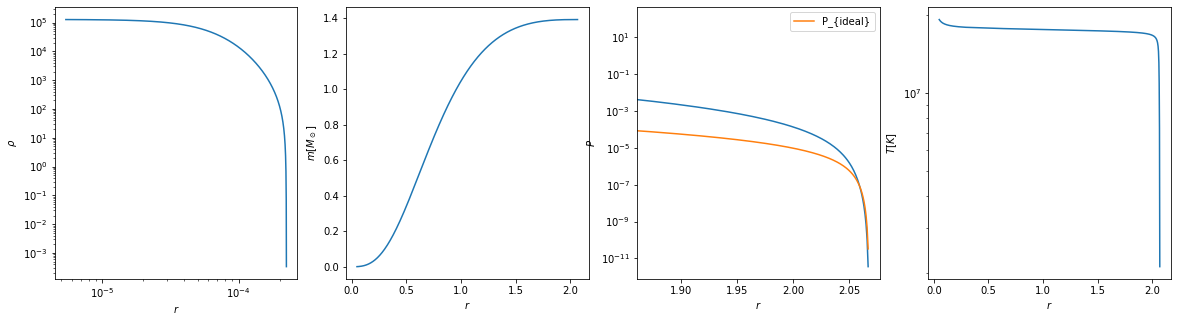

In [96]:
fig= plt.figure( figsize = ( 20, 5 ) )

Rstar = rr[0]*Rdim/1e8
plt.subplot(141)

plt.loglog(rr,rhowd)
plt.xlabel("$r$")
plt.ylabel("$\\rho$")

plt.subplot(142)

plt.plot(np.array(rr)*Rdim/1e8,np.array(masswd)*Mdim)

plt.xlabel("$r$")
plt.ylabel("$m [M_\\odot]$")


plt.subplot(143)

plt.semilogy(np.array(rr)*Rdim/1e8,pwd)
plt.semilogy(np.array(rr)*Rdim/1e8, np.array(rhowd) * np.array(TTwd), label="P_{ideal}" )

plt.xlim( 0.9*Rstar, 1.005*Rstar )
plt.legend()

plt.xlabel("$r$")
plt.ylabel("$P$")



plt.subplot(144)

plt.semilogy(np.array(rr)*Rdim/1e8, Tdim*np.array(TTwd))

#plt.xlim( 0.99*Rstar, 1.005*Rstar )
plt.xlabel("$r$")
plt.ylabel("$T [K]$")


#plt.ylim(9.9e6, 1.1e7)

plt.show()

In [9]:
rf = 1.0
dr = 5e-7
r0 = dr

grid_r = np.arange( 2.2, 10.1, 1.0 )
Nm = len(grid_r)

Lwd = 1e-4 * Lsun
Bwd = [0,0]
StarWD = np.zeros((2,Nm))

for i in range(Nm):
    print(i, grid_r[i])
    Rwd = grid_r[i]*1e8

    MR = Shooting_mass( Bwd[0]*Bdim, Bwd[0]*Bdim, Lwd , Rwd)
    StarWD[0,i] = MR[1]
    StarWD[1,i] = MR[2]

0 2.2


/tmp/ipykernel_59457/3549646311.py:19: RuntimeWarning: invalid value encountered in scalar power
  kappa0  = 0.1*kappaK * rhons / Twd**( 3.5 )
/tmp/ipykernel_59457/4223206718.py:7: RuntimeWarning: invalid value encountered in scalar power
  Bfield  = Bs + B0*( 1.0 - np.exp( -eta * x**gamma ) )
/tmp/ipykernel_59457/4223206718.py:8: RuntimeWarning: invalid value encountered in scalar power
  DBfield =  B0 *  np.exp( -eta * x**gamma )  * ( eta * gamma * x**(gamma - 1.0) ) / rho0


1 3.2
2 4.2
3 5.2
4 6.2
5 7.2
6 8.2
7 9.2


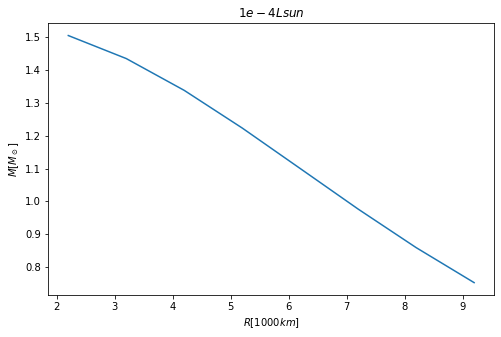

In [10]:
fig = plt.figure(figsize=(8,5))
plt.plot(StarWD[1,:]*Rdim*1e-8, StarWD[0,:]*Mdim, "-")

plt.ylabel("$M [M_\\odot]$")
plt.xlabel("$R [1000 km]$")

plt.title("$1e-4 Lsun$")

plt.show()

In [134]:
def TOV_op(r,y, Lr, Bs, B0):
    mns   = y[0]
    rhons = y[1]
    nuns  = y[2]
    Twd   = y[3]
    
    pns    =  EoS_RFMT(rhons)
    dPdrho = 1.0 / DeDpF(pns)
    BB     = Magnetic(rhons, Bs, B0)
    BB2    = BB[0]**2
    PB     = BB2 /( 8.0*np.pi )
    rhoB   = BB2 / ( 8.0*np.pi )
    Dbdrho = BB[0]*BB[1] / ( 4.0*np.pi  )

    Pideal = Twd * rhons

    rhostar = rhons + rhoB
    Pstar   = pns + PB + Pideal
    kappa0  = (1.0/op.opacity(12, 6, rhons*Sigma02, Tdim*Twd) ) * ( c2 / G ) *( 1 / Rdim)
    #kappa0  = 0.1*kappaK * rhons / Twd**( 3.5 )

    r2   = r*r
    r3   = r2*r
    ec1  = 4.0 * np.pi * r2 * rhostar
    ec2  = 2.0 * ( 4.0 * np.pi * r3 * Pstar + mns ) / ( r * ( r - 2.0 * mns ) )

    if r > 10*Pideal:
        ec4 = 0.0
    else:
        ec4  = - ( 3.0 / 16.0 ) * kappa0 * ( rhostar / Twd**3 ) * ( Lr / r2)

    ec3  = ( -0.5 * ec2 * ( Pstar + rhostar ) -  ec4*rhons ) / ( Dbdrho + dPdrho + Twd  )
            
    
    return np.array( [ ec1, ec3, ec2, ec4 ])

In [135]:
WDmag = ode(TOV_op).set_integrator('dopri5', method="Adams")

#----Loop to calculate Static sequence--------

def StaticSeq_inout(y0, drr,rf, Lrr,Bss, B00 ):
    global pwd, rhowd, TTwd,rr
    #r0 = drr*1e-2

    pwd   = [ ]
    rhowd = [ ]
    TTwd   = [ ]
    rr    = [ ]
   
    WDmag.set_initial_value(y0,drr).set_f_params( Lrr,Bss,B00)

    while WDmag.successful() and WDmag.t<rf and WDmag.y[1]*Sigma02 > 1e-8 and WDmag.y[1]>0.0:

        WDmag.integrate(WDmag.t+drr) 

        rhowd.append( WDmag.y[1] )
        TTwd.append( WDmag.y[3] )
        pwd.append( EoS_RFMT( WDmag.y[1]) )
        rr.append( WDmag.t )
      
        rstar = WDmag.t
        mstar = WDmag.y[0]
    
    print(WDmag.y[1]*Sigma02)
    print(WDmag.successful(), TOV_op(WDmag.t,WDmag.y, Lrr,Bss,B00))
    
    return [mstar,rstar]

In [136]:
rf = 1.0
dr = 1e-8
r0 = dr

rholog = 8.9
rhoc = np.power(10.0, rholog) / Sigma02 
pc   = EoS_RFMT( rhoc )

Bwd =  [0,0]
Ts  = 1e7 / Tdim
Lwd = 1e-2 * Lsun/ Ldim

M1 = StaticSeq_inout([0.0, rhoc, 0.0, Ts], dr, rf, Lwd,  Bwd[0] * Bdim, Bwd[1] * Bdim)
print(M1[0]*Mdim, M1[1]*Rdim/Rsun)

1.948041377935652e-09
False [ 1.24504010e-19 -3.62081369e+01  5.37705087e+00  0.00000000e+00]
1.3495482859817431 0.0037659654101366235


/tmp/ipykernel_61652/4223206718.py:7: RuntimeWarning: invalid value encountered in scalar power
  Bfield  = Bs + B0*( 1.0 - np.exp( -eta * x**gamma ) )
/tmp/ipykernel_61652/4223206718.py:8: RuntimeWarning: invalid value encountered in scalar power
  DBfield =  B0 *  np.exp( -eta * x**gamma )  * ( eta * gamma * x**(gamma - 1.0) ) / rho0


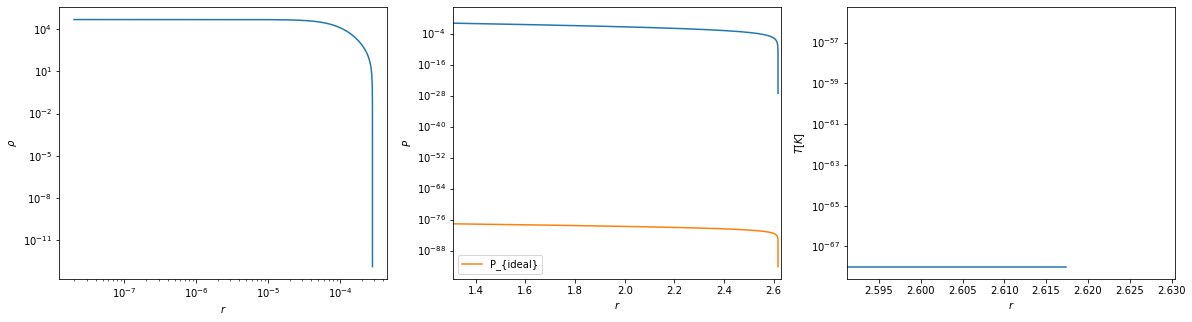

In [137]:
fig= plt.figure( figsize = ( 20, 5 ) )

Rstar = rr[-1]*Rdim/1e8
plt.subplot(131)

plt.loglog(rr,rhowd)
plt.xlabel("$r$")
plt.ylabel("$\\rho$")

plt.subplot(132)

plt.semilogy(np.array(rr)*Rdim/1e8,pwd)
plt.semilogy(np.array(rr)*Rdim/1e8, np.array(rhowd) * np.array(TTwd), label="P_{ideal}" )

plt.xlim( 0.5*Rstar, 1.005*Rstar )
plt.legend()

plt.xlabel("$r$")
plt.ylabel("$P$")

plt.subplot(133)

plt.semilogy(np.array(rr)*Rdim/1e8, Tdim*np.array(TTwd))

plt.xlim( 0.99*Rstar, 1.005*Rstar )
plt.xlabel("$r$")
plt.ylabel("$T [K]$")


#plt.ylim(9.9e6, 1.1e7)

plt.show()

In [133]:
1e6/Rdim

np.float64(1.0837361295542636e-06)